# Enxergando a distribuição

**Tema:** Estatística › Fundamentos e Estatística Descritiva

Este notebook defende uma tese simples e incômoda: **nenhuma tabela de
estatísticas-resumo é suficiente**. Vamos provar isso com dados construídos
especificamente para humilhar quem confia em `describe()`.

> **Analogia:** as estatísticas-resumo são o resultado de um exame de sangue.
> Elas dizem que algo está fora da faixa, mas não dizem *o quê*. O gráfico é a
> radiografia. Nenhum médico competente opera só com o exame de sangue.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(11)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("pronto")

pronto


## 1. O quarteto de Anscombe

Em 1973, o estatístico Francis Anscombe construiu quatro conjuntos de 11 pontos
com médias, variâncias, correlação e reta de regressão **praticamente
idênticas**. Eles são o argumento definitivo a favor do gráfico.

In [2]:
anscombe = pd.DataFrame({
    "x1": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y1": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    "x2": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y2": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    "x3": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y3": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    "x4": [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    "y4": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
})

linhas = []
for k in range(1, 5):
    x, y = anscombe[f"x{k}"].to_numpy(), anscombe[f"y{k}"].to_numpy()
    reta = stats.linregress(x, y)
    linhas.append({
        "conjunto": f"#{k}",
        "média x": x.mean(), "variância x": x.var(ddof=1),
        "média y": y.mean(), "variância y": y.var(ddof=1),
        "correlação": np.corrcoef(x, y)[0, 1],
        "intercepto": reta.intercept, "inclinação": reta.slope,
        "R²": reta.rvalue ** 2,
    })

pd.DataFrame(linhas).set_index("conjunto").round(3)

,média x,variância x,média y,variância y,correlação,intercepto,inclinação,R²
conjunto,,,,,,,,
#1,9.0,11.0,7.501,4.127,0.816,3.000,0.5,0.667
#2,9.0,11.0,7.501,4.128,0.816,3.001,0.5,0.666
#3,9.0,11.0,7.500,4.123,0.816,3.002,0.5,0.666
#4,9.0,11.0,7.501,4.123,0.817,3.002,0.5,0.667


Sete estatísticas, quatro conjuntos, valores praticamente iguais em todas as
células. Um relatório automatizado declararia os quatro equivalentes.

Agora o gráfico.

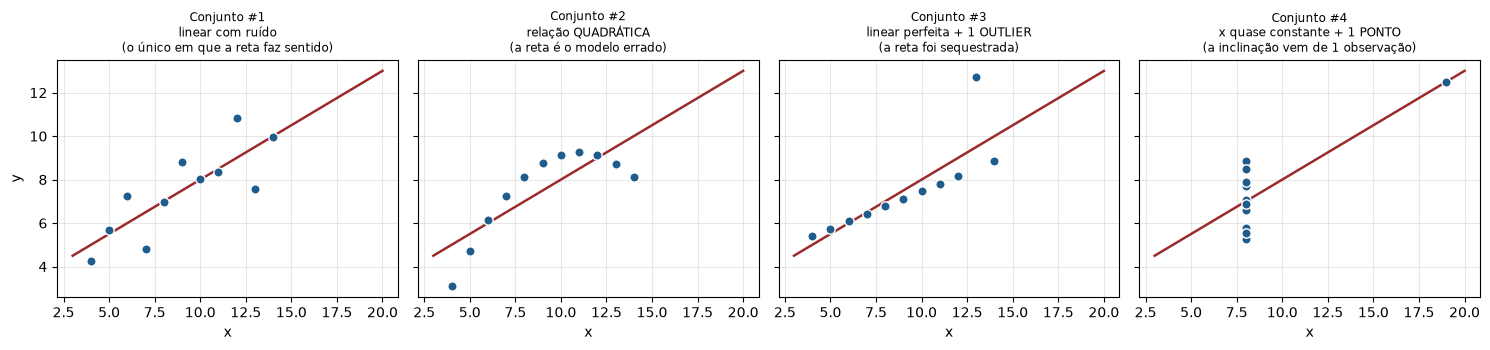

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, sharey=True)
diagnosticos = [
    "linear com ruído\n(o único em que a reta faz sentido)",
    "relação QUADRÁTICA\n(a reta é o modelo errado)",
    "linear perfeita + 1 OUTLIER\n(a reta foi sequestrada)",
    "x quase constante + 1 PONTO\n(a inclinação vem de 1 observação)",
]
for k, (ax, diag) in enumerate(zip(axes, diagnosticos), start=1):
    x, y = anscombe[f"x{k}"].to_numpy(), anscombe[f"y{k}"].to_numpy()
    reta = stats.linregress(x, y)
    grade = np.linspace(3, 20, 50)
    ax.scatter(x, y, s=45, color="#1F5C8B", zorder=3, edgecolor="white")
    ax.plot(grade, reta.intercept + reta.slope * grade, color="#9C2B2B", lw=1.8)
    ax.set_title(f"Conjunto #{k}\n{diag}", fontsize=8.5)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

Quatro histórias completamente diferentes, o mesmo resumo numérico. E cada uma
exige uma ação distinta do analista:

| Conjunto | Diagnóstico | O que fazer |
|---|---|---|
| #1 | Relação linear genuína | Seguir com regressão linear |
| #2 | Relação quadrática | Adicionar termo $x^2$ ou usar modelo não-linear |
| #3 | Um outlier domina | Investigar o ponto; usar regressão robusta |
| #4 | Sem variação em $x$ | A inclinação é indeterminada — não há o que modelar |

## 2. O histograma mente conforme o número de *bins*

O histograma tem um parâmetro livre — a largura do intervalo — e a escolha dele
muda a conclusão. Vamos ver a **mesma amostra bimodal** parecer unimodal.

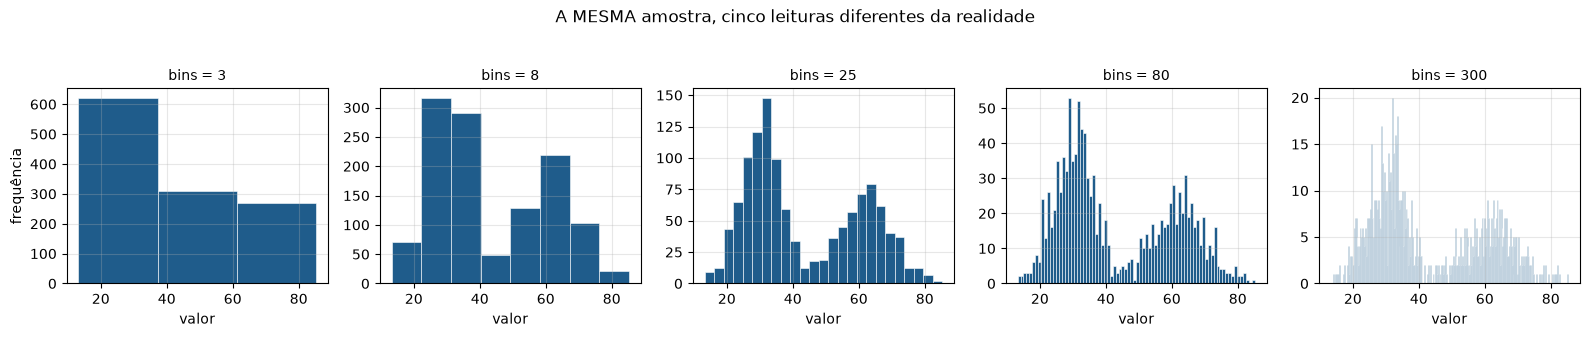

Com bins=3 os dois grupos somem. Com bins=300 o ruído vira sinal.
Regras automáticas de largura de bin:
   sturges    ->  12 bins
   scott      ->  13 bins
   fd         ->  13 bins


In [4]:
# Duas populações misturadas: exatamente o que acontece quando você junta
# clientes B2B e B2C, ou usuários mobile e desktop, na mesma coluna.
bimodal = np.concatenate([
    rng.normal(loc=30, scale=6, size=700),
    rng.normal(loc=62, scale=8, size=500),
])

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=False)
for ax, bins in zip(axes, [3, 8, 25, 80, 300]):
    ax.hist(bimodal, bins=bins, color="#1F5C8B", edgecolor="white", linewidth=0.4)
    ax.set_title(f"bins = {bins}", fontsize=10)
    ax.set_xlabel("valor")
axes[0].set_ylabel("frequência")
plt.suptitle("A MESMA amostra, cinco leituras diferentes da realidade", y=1.04)
plt.tight_layout()
plt.show()

print("Com bins=3 os dois grupos somem. Com bins=300 o ruído vira sinal.")
print("Regras automáticas de largura de bin:")
for regra in ["sturges", "scott", "fd"]:   # fd = Freedman-Diaconis
    n_bins = len(np.histogram_bin_edges(bimodal, bins=regra)) - 1
    print(f"   {regra:10s} -> {n_bins:3d} bins")

> **Recomendação prática:** use **Freedman-Diaconis** (`bins="fd"`) como
> default. Ele usa o IQR em vez do desvio-padrão, então é robusto a caudas.
> E, principalmente: **nunca olhe um único histograma**. Varie os bins.

## 3. A ECDF: o gráfico sem parâmetros livres

A função de distribuição acumulada empírica não tem *bins*, não tem largura de
banda, não tem nada para você escolher errado. Ela mostra **todos** os dados.

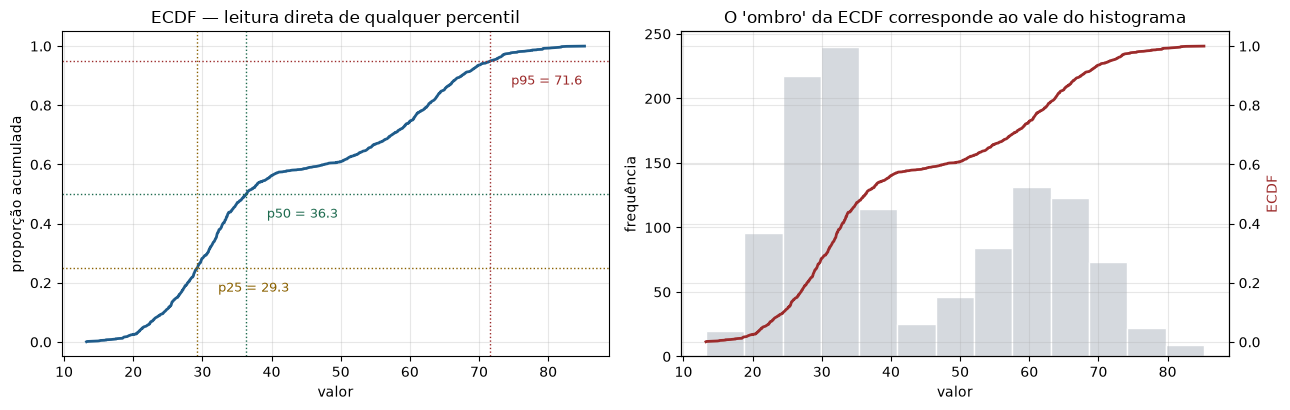

In [5]:
def ecdf(v):
    """Retorna (valores ordenados, proporção acumulada)."""
    v = np.sort(v)
    return v, np.arange(1, len(v) + 1) / len(v)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

xs, ys = ecdf(bimodal)
ax1.plot(xs, ys, lw=2, color="#1F5C8B")
for q, cor in [(0.25, "#8A6100"), (0.50, "#1E6B4F"), (0.95, "#9C2B2B")]:
    valor = np.quantile(bimodal, q)
    ax1.axhline(q, ls=":", lw=1, color=cor)
    ax1.axvline(valor, ls=":", lw=1, color=cor)
    ax1.annotate(f"p{int(q*100)} = {valor:.1f}", xy=(valor, q),
                 xytext=(valor + 3, q - 0.08), fontsize=9, color=cor)
ax1.set_title("ECDF — leitura direta de qualquer percentil")
ax1.set_xlabel("valor")
ax1.set_ylabel("proporção acumulada")

# O "degrau" da ECDF na região entre as modas é o que denuncia a bimodalidade:
# a curva fica quase plana onde há poucos dados.
ax2.hist(bimodal, bins="fd", color="#D5D9DE", edgecolor="white")
ax2b = ax2.twinx()
ax2b.plot(xs, ys, lw=2, color="#9C2B2B")
ax2b.set_ylabel("ECDF", color="#9C2B2B")
ax2.set_title("O 'ombro' da ECDF corresponde ao vale do histograma")
ax2.set_xlabel("valor")
ax2.set_ylabel("frequência")

plt.tight_layout()
plt.show()

## 4. Boxplot vs. violino: o que o boxplot esconde

O boxplot mostra 5 números. Isso é uma virtude (compacto, comparável) e um
defeito grave: **ele é cego para bimodalidade**.

amostra        mediana       Q1       Q3      IQR
Uniforme          49.2     37.5     62.2     24.7
Normal            50.6     38.3     62.3     24.0
Bimodal           49.8     37.6     62.5     24.9


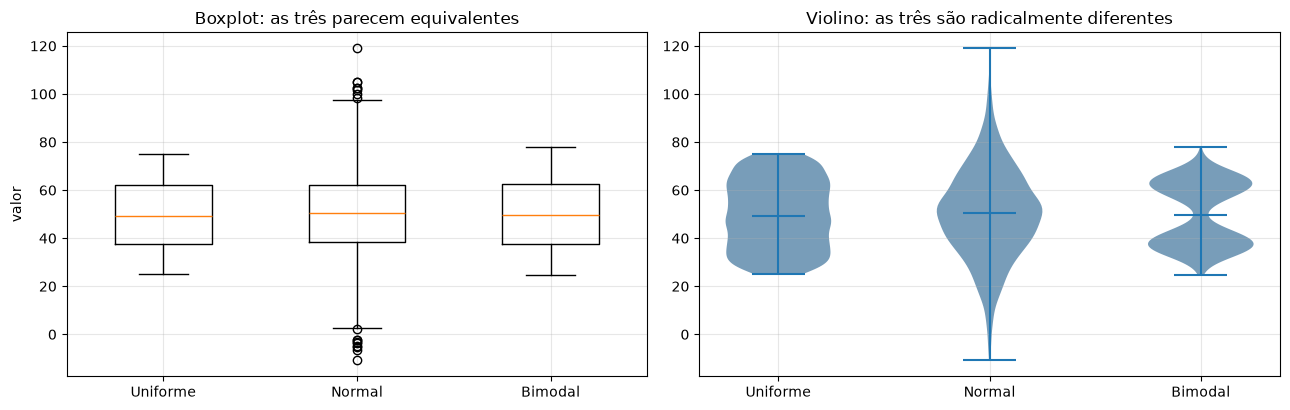

In [6]:
# Três amostras calibradas para ter MEDIANA ~50 e IQR ~24,4 — e formatos opostos.
# A calibração não é mágica, é aritmética de quantis:
#   uniforme(a, b)  -> IQR = (b - a) / 2          => b - a = 50
#   normal(mu, s)   -> IQR = 1.349 * s            => s = 25 / 1.349
#   mistura 50/50 de duas normais em mu ± d -> IQR ≈ 2d  => d = 12.5
n = 1200
uniforme = rng.uniform(25, 75, n)
normal_est = rng.normal(50, 25 / 1.349, n)
duas_modas = np.concatenate([rng.normal(37.5, 4.5, n // 2),
                             rng.normal(62.5, 4.5, n // 2)])

amostras = {"Uniforme": uniforme, "Normal": normal_est, "Bimodal": duas_modas}

print(f"{'amostra':12s} {'mediana':>9s} {'Q1':>8s} {'Q3':>8s} {'IQR':>8s}")
for nome, v in amostras.items():
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    print(f"{nome:12s} {med:>9.1f} {q1:>8.1f} {q3:>8.1f} {q3-q1:>8.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.boxplot(amostras.values(), tick_labels=amostras.keys(), widths=0.5)
ax1.set_title("Boxplot: as três parecem equivalentes")
ax1.set_ylabel("valor")

partes = ax2.violinplot(list(amostras.values()), showmedians=True)
for corpo in partes["bodies"]:
    corpo.set_facecolor("#1F5C8B")
    corpo.set_alpha(0.6)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(amostras.keys())
ax2.set_title("Violino: as três são radicalmente diferentes")

plt.tight_layout()
plt.show()

Medianas e IQRs quase iguais; distribuições irreconciliáveis. O boxplot não
tem como mostrar isso — ele só conhece cinco números.

> **No mercado:** quando um teste A/B mostra "sem diferença na mediana do
> tempo de sessão", mas o violino revela que o grupo tratado virou **bimodal**
> (uma parte dos usuários adorou, outra abandonou), a conclusão de "sem efeito"
> é falsa e cara. O efeito médio nulo é a soma de dois efeitos opostos.

## 5. QQ-plot: a normalidade é razoável aqui?

O QQ-plot compara os quantis dos seus dados com os quantis teóricos de uma
distribuição de referência. Se os pontos caem sobre a diagonal, a referência
serve.

Ele é muito mais informativo que um teste de normalidade, porque mostra
**onde** a discrepância está — e quase sempre ela está nas caudas, que é
justamente onde as decisões de risco acontecem.

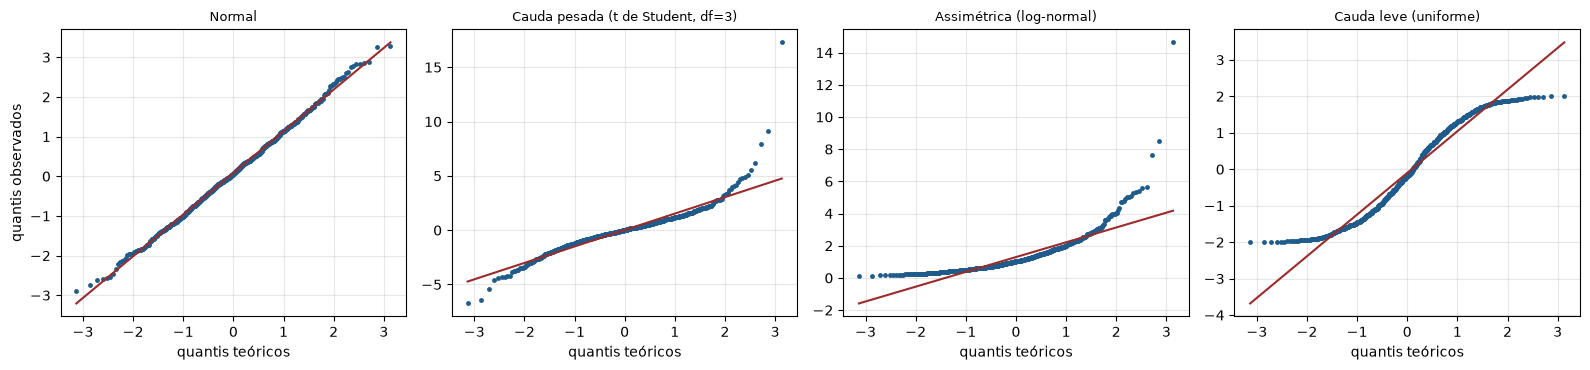

In [7]:
casos = {
    "Normal": rng.normal(0, 1, 800),
    "Cauda pesada (t de Student, df=3)": rng.standard_t(df=3, size=800),
    "Assimétrica (log-normal)": rng.lognormal(0, 0.7, 800),
    "Cauda leve (uniforme)": rng.uniform(-2, 2, 800),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (nome, v) in zip(axes, casos.items()):
    stats.probplot(v, dist="norm", plot=ax)
    ax.set_title(nome, fontsize=9.5)
    ax.get_lines()[0].set_markerfacecolor("#1F5C8B")
    ax.get_lines()[0].set_markeredgecolor("none")
    ax.get_lines()[0].set_markersize(3.5)
    ax.get_lines()[1].set_color("#9C2B2B")
    ax.set_xlabel("quantis teóricos")
    ax.set_ylabel("quantis observados" if ax is axes[0] else "")
plt.tight_layout()
plt.show()

Como ler cada assinatura:

* **Sobre a linha** → a referência normal descreve bem os dados.
* **Pontas viradas para cima nas duas extremidades** (formato de S invertido)
  → **caudas pesadas**: mais eventos extremos do que a normal prevê. É a
  assinatura de retorno financeiro, latência e valor de sinistro.
* **Curva convexa, subindo à direita** → **assimetria positiva**. Considere
  log-transformar.
* **Pontas viradas para dentro** → caudas leves; a normal está superestimando
  os extremos.

> **Por que não usar um teste de normalidade (Shapiro-Wilk, Kolmogorov-Smirnov)
> e pronto?** Porque o p-valor de um teste de normalidade é função do tamanho
> da amostra. Com $n = 50$ ele aceita quase tudo; com $n = 100.000$ ele rejeita
> **tudo**, porque nenhum dado real é exatamente normal. O teste responde "é
> exatamente normal?" (a resposta é sempre não) quando a pergunta útil é "o
> desvio da normalidade é grande o suficiente para importar?" — e essa só o
> gráfico responde. Vamos demonstrar isso.

In [8]:
# Uma t de Student com 50 graus de liberdade é visualmente indistinguível de uma
# normal — a diferença está apenas num leve excesso nas caudas. É exatamente o
# tipo de desvio que existe em TODO dado real.
quase_normal = rng.standard_t(df=50, size=300_000)

print(f"{'n':>9s} {'p-valor':>12s}   veredito ao nível de 5%")
print("-" * 52)
for n in [50, 300, 3_000, 30_000, 300_000]:
    # D'Agostino-Pearson para todos os tamanhos, para a comparação ser justa
    p = stats.normaltest(quase_normal[:n]).pvalue
    veredito = "REJEITA normalidade" if p < 0.05 else "não rejeita"
    print(f"{n:>9,} {p:>12.2e}   {veredito}")

print("\nA distribuição é a MESMA nas cinco linhas. O que mudou foi só o n.")
print("Com n pequeno o teste não tem poder para enxergar o desvio;")
print("com n grande ele enxerga um desvio que é irrelevante na prática.")

        n      p-valor   veredito ao nível de 5%
----------------------------------------------------
       50     9.59e-01   não rejeita
      300     7.78e-02   não rejeita
    3,000     3.69e-01   não rejeita
   30,000     1.17e-03   REJEITA normalidade
  300,000     3.46e-42   REJEITA normalidade

A distribuição é a MESMA nas cinco linhas. O que mudou foi só o n.
Com n pequeno o teste não tem poder para enxergar o desvio;
com n grande ele enxerga um desvio que é irrelevante na prática.


## 6. Correlação: o mapa de calor e suas cegueiras

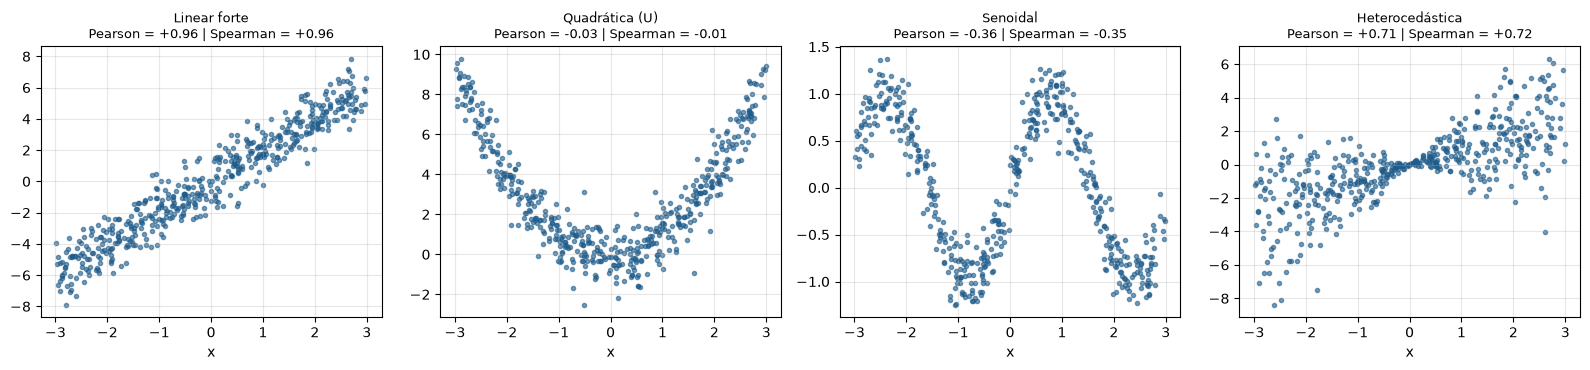

In [9]:
n = 500
x = rng.uniform(-3, 3, n)
relacoes = {
    "Linear forte": (x, 2 * x + rng.normal(0, 1, n)),
    "Quadrática (U)": (x, x ** 2 + rng.normal(0, 0.8, n)),
    "Senoidal": (x, np.sin(2 * x) + rng.normal(0, 0.2, n)),
    "Heterocedástica": (x, x + rng.normal(0, 1, n) * np.abs(x)),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (nome, (a, b)) in zip(axes, relacoes.items()):
    r_pearson = stats.pearsonr(a, b).statistic
    r_spearman = stats.spearmanr(a, b).statistic
    ax.scatter(a, b, s=9, color="#1F5C8B", alpha=0.6)
    ax.set_title(f"{nome}\nPearson = {r_pearson:+.2f} | Spearman = {r_spearman:+.2f}",
                 fontsize=9.5)
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

O painel **Quadrática** é o mais importante: Pearson perto de zero, e a
dependência é **determinística** — dado $x$, você sabe $y$ quase exatamente.
Uma matriz de correlação teria descartado essa variável como "irrelevante".

A **informação mútua** captura dependência de qualquer formato, porque mede
quanto conhecer $x$ reduz a incerteza sobre $y$:

In [10]:
from sklearn.feature_selection import mutual_info_regression

print(f"{'relação':20s} {'|Pearson|':>10s} {'|Spearman|':>11s} {'Info. mútua':>12s}")
print("-" * 58)
for nome, (a, b) in relacoes.items():
    mi = mutual_info_regression(a.reshape(-1, 1), b, random_state=0)[0]
    print(f"{nome:20s} {abs(stats.pearsonr(a, b).statistic):>10.3f} "
          f"{abs(stats.spearmanr(a, b).statistic):>11.3f} {mi:>12.3f}")

relação               |Pearson|  |Spearman|  Info. mútua
----------------------------------------------------------
Linear forte              0.961       0.963        1.244
Quadrática (U)            0.031       0.014        1.111
Senoidal                  0.363       0.354        1.077
Heterocedástica           0.708       0.723        0.586


Na linha "Quadrática", Pearson e Spearman ficam perto de zero e a informação
mútua é alta. É exatamente o comportamento desejado de um detector de
dependência.

## 7. Checklist visual antes de modelar

Para **cada variável numérica**:
1. Histograma com pelo menos 3 larguras de bin diferentes (ou ECDF).
2. Boxplot **ou** violino — violino se suspeitar de mistura de populações.
3. QQ-plot se algum método assumir normalidade.
4. Série temporal do valor, se houver carimbo de tempo (revela quebras de
   coleta, migrações de sistema e sazonalidade).

Para **cada par relevante**:
5. Scatter plot (com amostragem, se $n$ for grande, e transparência).
6. Pearson **e** Spearman lado a lado — a divergência entre os dois é
   diagnóstico de não-linearidade ou de outliers.

## 8. Exercícios

1. Reproduza o *Datasaurus Dozen*: 13 conjuntos com as mesmas estatísticas, um
   deles no formato de um dinossauro. Baixe de
   `https://www.openintro.org/data/index.php?data=datasaurus` e verifique.
2. Construa duas amostras com **a mesma média, o mesmo desvio-padrão e a mesma
   assimetria**, mas formatos visivelmente diferentes. Quantos momentos são
   necessários para "prender" uma distribuição?
3. Gere dados heterocedásticos e ajuste uma regressão linear. O $R^2$ detecta o
   problema? E o gráfico de resíduos versus valores ajustados?
4. Aplique a seção 5 aos resíduos de um modelo real. QQ-plot de resíduos é a
   ferramenta de diagnóstico número um em regressão — voltaremos a ele no tema
   *Aprendizado Supervisionado*.

## Próximo módulo

`02-distribuicoes-de-probabilidade/` — sai a descrição do que aconteceu, entra
a modelagem do que **pode** acontecer.